In [1]:
%load_ext autoreload
%autoreload 2
import kwant
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from koala.lattice import Lattice
from alter_morph.hamiltonians import alt_hamiltonian
from alter_morph.lattice_utilities import alter_lattice_maker,add_contacts
from alter_morph.mean_field import hartree_fock
from alter_morph.kwant_utilities import Amorphous


# plotting
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

First let us construct a regular PBC hamiltonian on our lattice, using all the methods from amorphous_mean_field

In [14]:
# generate the lattice and set the initial conditions

import koala.graph_utils

# create lattice
system_length = 10
lattice_type = "voronoi"
lattice = alter_lattice_maker(system_length, lattice_type)
lattice = koala.graph_utils.cut_boundaries(lattice, [False, True])

# set parameters, scan different values of J
t1 = 1  # orbital parallel neighbor hopping
t2 = 0.5  # orbital perpendicular neighbor hopping
Js = np.linspace(0.,1,21)  # Interaction strength
filling = 0.3  # filling of the lattice
theta_offset = np.pi/4 #global rotation of the orbitals

tol_mdiff = 1e-3
n_fock_steps = 300  # number of Hartree-Fock steps
lead_symmetry = np.diag([-1,-1,1,1])

results = []

for J in Js:
    initial_m = np.full(lattice.n_vertices, 1)  # initial magnetization
    initial_parameters = {
        "t1": t1,
        "t2": t2,
        "J": J,
        "U": J,
        "filling": filling,
        "initial_m": initial_m,
        "initial_n": np.full(lattice.n_vertices, filling * 4),
        "theta_offset": theta_offset
    }


    m_values,n_values = hartree_fock(lattice, initial_parameters, n_fock_steps,tol_mdiff=1e-2)

    # make ham and solve
    hamiltonian = alt_hamiltonian(
        lattice,
        initial_parameters["t1"],
        initial_parameters["t2"],
        initial_parameters["J"],
        initial_parameters["U"],
        m_values[-1],
        n_values[-1],
        theta_offset = initial_parameters['theta_offset']
    )
    energies, states = la.eigh(hamiltonian)

    results.append(dict(initial_m=initial_m,initial_parameters=initial_parameters,m_values=m_values,n_values=n_values,lattice=lattice))



Avg:1.20, diff: 0.000178:   2%|▏         | 7/300 [00:00<00:15, 18.97it/s]


1.0


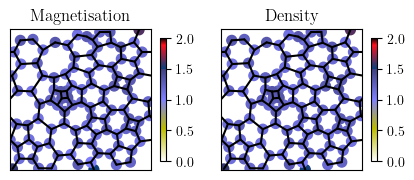

In [27]:
# plot that shit for one J
idx = -1
J = Js[idx]
print(J)
m_values = results[idx]['m_values']
n_values = results[idx]['n_values']

fig, axs = plt.subplots(1, 2, figsize=(5, 4))

for ax,label,plot_values in zip(axs,["Magnetisation","Density"],[m_values[-1],n_values[-1]]):
    pl.plot_edges(lattice, ax=ax)
    im = ax.scatter(
        lattice.vertices.positions[:, 0],
        lattice.vertices.positions[:, 1],
        c=plot_values,
        cmap="gist_stern_r",
        s=50,
        vmin=0,
        vmax=2,
    )
    plt.colorbar(im, ax=ax,shrink=0.4)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(label)
    # print(lattice)




In [16]:
from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)

for result in results:

    hamiltonian = alt_hamiltonian(
        result['lattice'],
        result['initial_parameters']["t1"],
        result['initial_parameters']["t2"],
        result['initial_parameters']["J"],
        result['initial_parameters']["U"],
        result['m_values'][-1],
        result['n_values'][-1],
    )

    n_orbitals = 4
    lead_onsite = np.eye(n_orbitals)
    lead_coupling = np.eye(n_orbitals)

    contact_lattice, k_lattice, k_system, contact_vertices = (
        crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
    )
    kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
        contact_lattice, k_lattice, k_system, contact_vertices, lead_onsite, lead_coupling, lead_symmetry
    )

    k_system_f = k_system.finalized()
    smatrix = kwant.smatrix(k_system_f)
    g = np.array([[smatrix.transmission((1,j),(0,i)) for j in range(2)] for i in range(2)])
    result['spin_cond'] = g

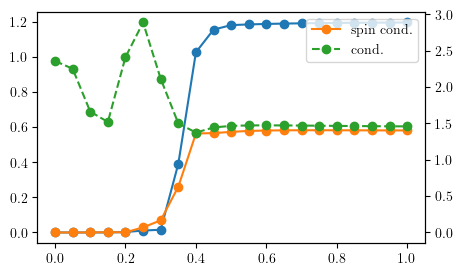

In [17]:
g_spin = np.abs([result['spin_cond'][0,0]-result['spin_cond'][1,1] for result in results])
g = np.abs([result['spin_cond'][0,0]+result['spin_cond'][1,1] for result in results])

m_avg = [result['m_values'][-1].mean() for result in results]

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
axL = ax.twinx()
ax.plot(Js,m_avg,'-o',color='tab:blue',label='avg. magnetization')
axL.plot(Js,g_spin,'-o',color='tab:orange',label='spin cond.')
axL.plot(Js,g,'--o',color='tab:green',label='cond.')

axL.legend()

In [ ]:
# spectral function
# plot that shit for one J

from alter_morph.hamiltonians import spectral_function


fig,axs = plt.subplots(len(results),1)

for result,ax in zip(results,axs):

    

for j in range(d["data"].shape[1]):

    data_entry = d["data"][idx_n, j]

    hamiltonian = alt_hamiltonian(
        lattice,
        data_entry["hparam"]["t1"],
        data_entry["hparam"]["t2"],
        data_entry["hparam"]["J"],
        data_entry["hparam"]["m"],
        theta_offset=data_entry["hparam"]["theta_offset"],
    )

    # evaluating the Fermi energy
    energies, states = la.eigh(hamiltonian)
    fermi_energy = energies[
        int(data_entry["hparam"]["filling"] * len(energies))
    ]  # better algorithm to get Fermi energy

    n_orbitals = 4
    lead_onsite = np.eye(n_orbitals)
    lead_coupling = np.eye(n_orbitals)

    contact_lattice, k_lattice, k_system, contact_vertices = (
        crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
    )
    kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
        contact_lattice,
        k_lattice,
        k_system,
        contact_vertices,
        lead_onsite,
        lead_coupling,
        lead_symmetry,
    )

    ##evaluate at fermi_energie!

    k_system_f = k_system.finalized()
    smatrix = kwant.smatrix(k_system_f, energy=fermi_energy)
    g = np.array(
        [[smatrix.transmission((1, j), (0, i)) for j in range(2)] for i in range(2)]
    )

    g_spin.append(g[0, 0] - g[1, 1])
    fermi_energies.append(fermi_energy)

    spectral_functions_up.append(
        spectral_function(
            lattice,
            energies,
            states,
            fermi_energy,
            local_projector=np.array([1, 0, 0, 0]),
            eta=1e-1,
            n_k=50,
        )
    )
    spectral_functions_dw.append(
        spectral_function(
            lattice,
            energies,
            states,
            fermi_energy,
            local_projector=np.array([0, 0, 0, 1]),
            eta=1e-1,
            n_k=50,
        )
    )

